# MVP UI Demo: Full Cycle Entry Point

Этот notebook — каноническая пользовательская точка входа поверх полного пайплайна `run_full_cycle` только по листу `"Общее"`.

- `MODE = "full"` — полное переобучение и пересборка артефактов.
- `MODE = "fast"` — повторный запуск с уже сохраненной моделью.

Базовый сценарий: `Restart Kernel` -> `Run All`.


In [1]:
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found (expected pyproject.toml and src/).")

PROJECT_ROOT = find_project_root(Path.cwd())
INPUT_PATH = PROJECT_ROOT / "data" / "raw" / "episodes.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "demo_run"
MODEL_PATH = OUTPUT_DIR / "models" / "hmm_model.pkl"

SHEET_NAMES = ["Общее"]
HEADER_DEPTH = 4
MODE = "full"  # "full" | "fast"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"INPUT_PATH: {INPUT_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"SHEET_NAMES: {SHEET_NAMES}")
print(f"HEADER_DEPTH: {HEADER_DEPTH}")
print(f"MODE: {MODE}")

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Input Excel not found: {INPUT_PATH}")


PROJECT_ROOT: /Users/dmitryaleshkin/Documents/hidden-patterns-combat
INPUT_PATH: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx
OUTPUT_DIR: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run
MODEL_PATH: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl
SHEET_NAMES: ['Общее']
HEADER_DEPTH: 4
MODE: full


In [2]:
# Optional: ручная очистка перед полным прогоном.
# По умолчанию удаление отключено, чтобы `Run All` был безопасным.

import shutil

RUN_CLEANUP = False  # Переключите в True и запустите ячейку вручную при необходимости

if RUN_CLEANUP:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
        print(f"Removed: {OUTPUT_DIR}")
    else:
        print(f"Nothing to remove: {OUTPUT_DIR}")
else:
    print("Cleanup skipped (RUN_CLEANUP=False).")


Cleanup skipped (RUN_CLEANUP=False).


In [3]:
from hidden_patterns_combat.app.full_cycle import run_full_cycle

result = run_full_cycle(
    input_path=INPUT_PATH,
    output_dir=OUTPUT_DIR,
    sheet_names=SHEET_NAMES,
    header_depth=HEADER_DEPTH,
    mode=MODE,
    model_path=MODEL_PATH,
)

result.as_dict()


[1/8] Preprocessing Excel input... requested_sheets=['Общее']
      loaded_sheets=['Общее']
[2/8] Feature engineering...
[3/8] Preparing HMM sequences...
[4/8] Training/loading model...


HMM finished with negative monitor delta: delta=-0.034025 (possible local instability).


      convergence_note=negative final monitor delta; model may be in a local unstable optimum.
[5/8] Decoding hidden states and running analysis...
[6/8] Generating visualizations...
[7/8] Writing summary/report...
[8/8] Full cycle completed.


{'input_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx',
 'output_dir': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run',
 'requested_sheets': ['Общее'],
 'loaded_sheets': ['Общее'],
 'cleaned_data_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/cleaned_tidy.csv',
 'features_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/engineered_feature_set.csv',
 'model_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl',
 'report_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/reports/full_cycle_report.md',
 'plots_dir': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots',
 'diagnostics_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/hmm_state_interpretation.csv',
 'n_rows_raw': 967,
 'n_r

In [4]:
import json
import pandas as pd
from IPython.display import Markdown, display

diagnostics_csv = OUTPUT_DIR / "diagnostics" / "hmm_state_interpretation.csv"
semantic_json = OUTPUT_DIR / "diagnostics" / "semantic_diagnostics.json"
report_md = OUTPUT_DIR / "reports" / "full_cycle_report.md"

payload = result.as_dict()
mapping = payload.get("canonical_state_mapping", {})
observed_signal = payload.get("observed_signal", {})

print("Canonical state order:", payload.get("canonical_state_order"))
print("Canonical state mapping:", mapping)
print("Semantic assignment:", payload.get("semantic_assignment"))
print("Semantic confidence:", payload.get("semantic_confidence"))
print("Transition alignment:", payload.get("transition_alignment"))
print("Semantic order matched topology before reorder:", payload.get("semantic_order_matches_topology_before_reorder"))

print("Observed signal block:")
print(json.dumps(observed_signal, ensure_ascii=False, indent=2))
if not observed_signal.get("is_direct_observed_zap", False):
    print("WARNING: observed signal is proxy, not direct observed ZAP.")

warnings = payload.get("semantic_warnings", [])
if warnings:
    print("Warnings:")
    for w in warnings:
        print(" -", w)
else:
    print("Warnings: none")


consistency_warnings = payload.get("consistency_warnings", [])
if consistency_warnings:
    print("Consistency warnings:")
    for w in consistency_warnings:
        print(" -", w)
else:
    print("Consistency warnings: none")
transition_summary = payload.get("transition_summary", [])
if transition_summary:
    print("Top transitions:")
    display(pd.DataFrame(transition_summary).head(10))
else:
    print("Transition summary is empty.")

if diagnostics_csv.exists():
    print(f"Diagnostics: {diagnostics_csv}")
    display(pd.read_csv(diagnostics_csv))
else:
    print(f"Diagnostics file not found: {diagnostics_csv}")

if semantic_json.exists():
    print(f"Semantic diagnostics: {semantic_json}")
    display(Markdown(f"```json\n{semantic_json.read_text(encoding='utf-8')}\n```"))
else:
    print(f"Semantic diagnostics file not found: {semantic_json}")

if report_md.exists():
    print(f"Report: {report_md}")
    display(Markdown(report_md.read_text(encoding="utf-8")))
else:
    print(f"Report file not found: {report_md}")


Canonical state order: ['S1', 'state_0', 'state_1']
Canonical state mapping: {'n_states': 3, 'canonical_state_ids': [0, 1, 2], 'canonical_state_names': ['S1', 'state_0', 'state_1'], 'canonical_to_name': {0: 'S1', 1: 'state_0', 2: 'state_1'}, 'canonical_to_original': {0: 2, 1: 0, 2: 1}, 'original_to_canonical': {2: 0, 0: 1, 1: 2}, 'state_order_used_for_transitions': [0, 1, 2], 'semantic_assignment': {'S1': 0}, 'semantic_confidence': {'S1': 0.4085516987731055, 'S2': 0.0, 'S3': 0.0}, 'semantic_order_matches_topology_before_reorder': False}
Semantic assignment: {'S1': 0}
Semantic confidence: {'S1': 0.4085516987731055, 'S2': 0.0, 'S3': 0.0}
Transition alignment: {'forward_share': 0.12268518518518519, 'backward_share': 0.0, 'self_share': 0.8773148148148148}
Semantic order matched topology before reorder: False
Observed signal block:
{
  "signal_column": "observed_result",
  "signal_label": "Observed proxy score",
  "source_columns": [
    "outcomes__score"
  ],
  "available_outcome_columns":

,from_state,to_state,from_name,to_name,count,share
0,0,0,S1,S1,478,0.553241
1,2,2,state_1,state_1,192,0.222222
2,1,1,state_0,state_0,88,0.101852
3,0,1,S1,state_0,54,0.062500
4,1,2,state_0,state_1,52,0.060185


Diagnostics: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/hmm_state_interpretation.csv


,state_id,maneuver_right_code,maneuver_left_code,grips_code,holds_code,bodylocks_code,underhooks_code,posts_code,kfv_code,vup_code,...,duration,pause,observed_result,episodes_count,state_name,raw_hidden_state,posthoc_interpretation,semantic_label,semantic_confidence,canonical_state_id
0,0,3.747135,1.511869,1.941864,0.230835,0.617997,0.022939,0.021215,5.587770,0.713251,...,27.581315,10.077855,0.295848,578,S1,S1,Пост-хок: состояние характеризуется повышенной...,S1,0.408552,0
1,1,3.215344,2.063553,1.660287,0.690532,0.172760,0.634612,0.356495,11.181222,0.929786,...,23.288732,13.133803,0.415493,142,state_0,state_0,Пост-хок: состояние характеризуется повышенной...,NaN,0.000000,1
2,2,3.180000,1.297100,2.176423,0.000000,0.605744,0.462529,0.112448,8.050844,0.607417,...,22.815574,16.368852,0.336066,244,state_1,state_1,Пост-хок: состояние характеризуется повышенной...,NaN,0.000000,2


Semantic diagnostics: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/semantic_diagnostics.json


```json
{
  "canonical_state_order": [
    "S1",
    "state_0",
    "state_1"
  ],
  "canonical_state_indices": [
    0,
    1,
    2
  ],
  "semantic_assignment": {
    "S1": 0
  },
  "semantic_confidence": {
    "S1": 0.4085516987731055,
    "S2": 0.0,
    "S3": 0.0
  },
  "semantic_warnings": [
    "Semantic state S2 not confidently discovered from current data/profiles.",
    "Semantic state S3 not confidently discovered from current data/profiles.",
    "Semantic order differs from internal topology order before canonical reordering."
  ],
  "semantic_order_matches_topology_before_reorder": false,
  "transition_alignment": {
    "forward_share": 0.12268518518518519,
    "backward_share": 0.0,
    "self_share": 0.8773148148148148
  },
  "top_transitions": [
    {
      "from_state": 0,
      "to_state": 0,
      "from_name": "S1",
      "to_name": "S1",
      "count": 478,
      "share": 0.5532407407407407
    },
    {
      "from_state": 2,
      "to_state": 2,
      "from_name": "state_1",
      "to_name": "state_1",
      "count": 192,
      "share": 0.2222222222222222
    },
    {
      "from_state": 1,
      "to_state": 1,
      "from_name": "state_0",
      "to_name": "state_0",
      "count": 88,
      "share": 0.10185185185185185
    },
    {
      "from_state": 0,
      "to_state": 1,
      "from_name": "S1",
      "to_name": "state_0",
      "count": 54,
      "share": 0.0625
    },
    {
      "from_state": 1,
      "to_state": 2,
      "from_name": "state_0",
      "to_name": "state_1",
      "count": 52,
      "share": 0.06018518518518518
    }
  ],
  "canonical_state_mapping": {
    "n_states": 3,
    "canonical_state_ids": [
      0,
      1,
      2
    ],
    "canonical_state_names": [
      "S1",
      "state_0",
      "state_1"
    ],
    "canonical_to_name": {
      "0": "S1",
      "1": "state_0",
      "2": "state_1"
    },
    "canonical_to_original": {
      "0": 2,
      "1": 0,
      "2": 1
    },
    "original_to_canonical": {
      "2": 0,
      "0": 1,
      "1": 2
    },
    "state_order_used_for_transitions": [
      0,
      1,
      2
    ],
    "semantic_assignment": {
      "S1": 0
    },
    "semantic_confidence": {
      "S1": 0.4085516987731055,
      "S2": 0.0,
      "S3": 0.0
    },
    "semantic_order_matches_topology_before_reorder": false
  },
  "observed_signal": {
    "signal_column": "observed_result",
    "signal_label": "Observed proxy score",
    "source_columns": [
      "outcomes__score"
    ],
    "available_outcome_columns": [
      "outcomes__f02",
      "outcomes__f03",
      "outcomes__f04",
      "outcomes__f05",
      "outcomes__f06",
      "outcomes__f07",
      "outcomes__score"
    ],
    "direct_zap": false,
    "classification": "proxy",
    "is_direct_observed_zap": false,
    "caveat": "Current observed signal is a proxy score (numeric passthrough), not a direct observed ZAP variable. Dataset contains outcome score/actions, but no explicit observed ZAP column and no validated transformation rule from outcomes to direct ZAP."
  }
}
```

Report: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/reports/full_cycle_report.md


# Full Cycle Report

- Input file: `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx`
- Output dir: `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run`
- Requested sheets: `['Общее']`
- Loaded sheets: `['Общее']`
- Rows raw/clean: 967/964
- Engineered features: 11
- HMM input features: `['maneuver_right_code', 'maneuver_left_code', 'grips_code', 'holds_code', 'bodylocks_code', 'underhooks_code', 'posts_code', 'kfv_code', 'vup_code', 'duration', 'pause']`
- Dropped constant HMM features: `[]`
- HMM converged: True
- HMM iterations: 19
- HMM last delta: -0.03402463860197713
- Sequences: 94
- Model states: 3
- Canonical state order: ['S1', 'state_0', 'state_1']
- Semantic confidence: {'S1': 0.4085516987731055, 'S2': 0.0, 'S3': 0.0}
- Semantic assignment (canonical indices): {'S1': 0}
- Semantic order matched topology before reorder: False
- Transition alignment: {'forward_share': 0.12268518518518519, 'backward_share': 0.0, 'self_share': 0.8773148148148148}
- observed_result source columns: ['outcomes__score']
- observed_result note: Current observed signal is a proxy score (numeric passthrough), not a direct observed ZAP variable. Dataset contains outcome score/actions, but no explicit observed ZAP column and no validated transformation rule from outcomes to direct ZAP.

## Observed Signal
- Signal column: observed_result
- Signal label: Observed proxy score
- Source columns: ['outcomes__score']
- Is direct observed ZAP: False
- Classification: proxy
- Caveat: Current observed signal is a proxy score (numeric passthrough), not a direct observed ZAP variable. Dataset contains outcome score/actions, but no explicit observed ZAP column and no validated transformation rule from outcomes to direct ZAP.

## State Summary
- state=0, name=S1, episodes=578, result_mean=0.2958
- state=1, name=state_0, episodes=142, result_mean=0.4155
- state=2, name=state_1, episodes=244, result_mean=0.3361

## Transition Summary
- S1 -> S1: count=478, share=0.553
- state_1 -> state_1: count=192, share=0.222
- state_0 -> state_0: count=88, share=0.102
- S1 -> state_0: count=54, share=0.062
- state_0 -> state_1: count=52, share=0.060

## Semantic Warnings
- Semantic state S2 not confidently discovered from current data/profiles.
- Semantic state S3 not confidently discovered from current data/profiles.
- Semantic order differs from internal topology order before canonical reordering.

## Sample Analysis
- {"episode_id": "1.0", "sequence_id": "Общее::Акрамов Б.Б.", "hidden_state": 0, "hidden_state_name": "S1", "observed_result": 1.0, "probabilities": {"S1": 1.0, "state_0": 0.0, "state_1": 0.0}}

## Artifacts
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/raw_combined.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/cleaned_tidy.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/data_dictionary.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/validation.json`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/raw_feature_set.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/engineered_feature_set.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/feature_traceability.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/feature_validation.json`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/episode_analysis.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/state_profile.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/hmm_state_interpretation.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/interpretation.txt`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/semantic_diagnostics.json`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/athlete_comparative_profile.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/hidden_state_sequence.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/scenario_success_frequencies.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/state_probability_profile.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/transition_distribution.png`


Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/hidden_state_sequence.png


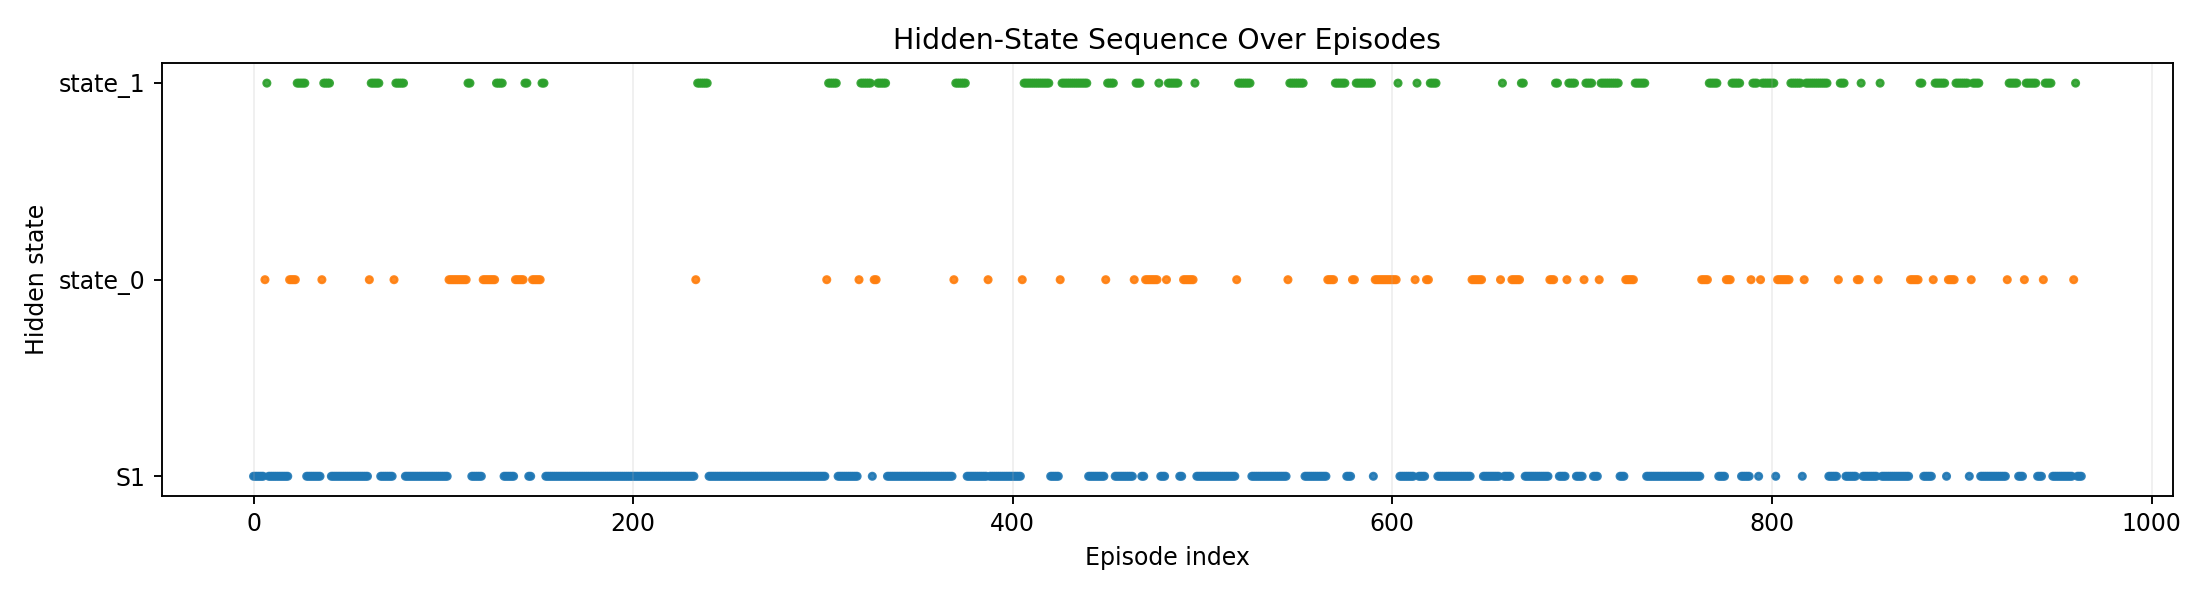

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/state_probability_profile.png


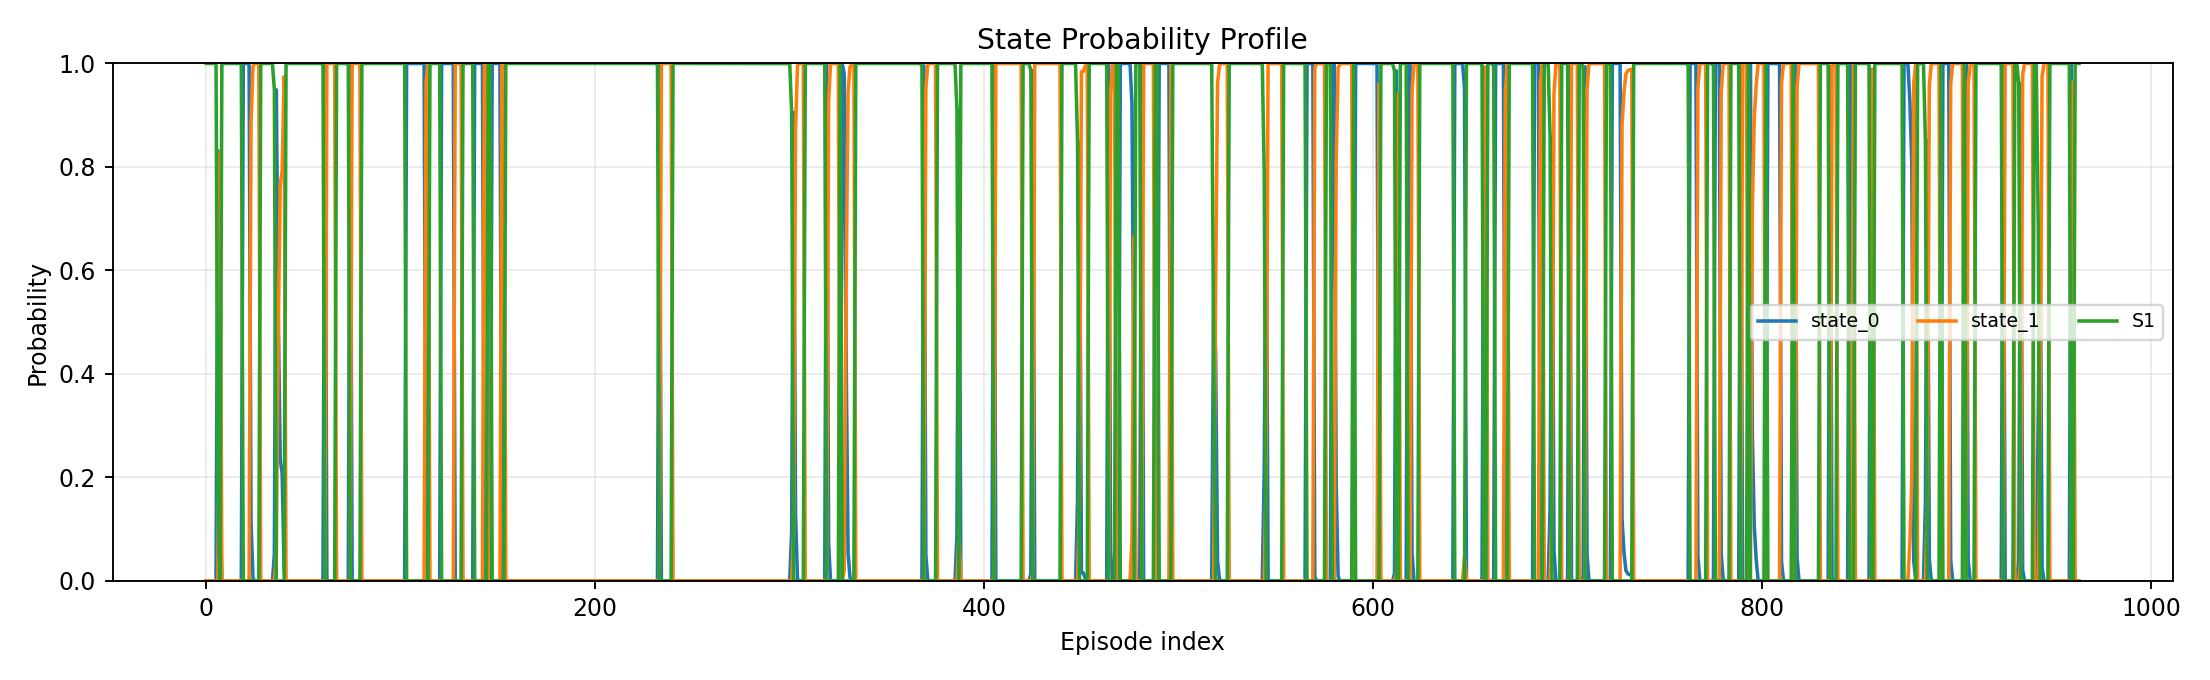

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/transition_distribution.png


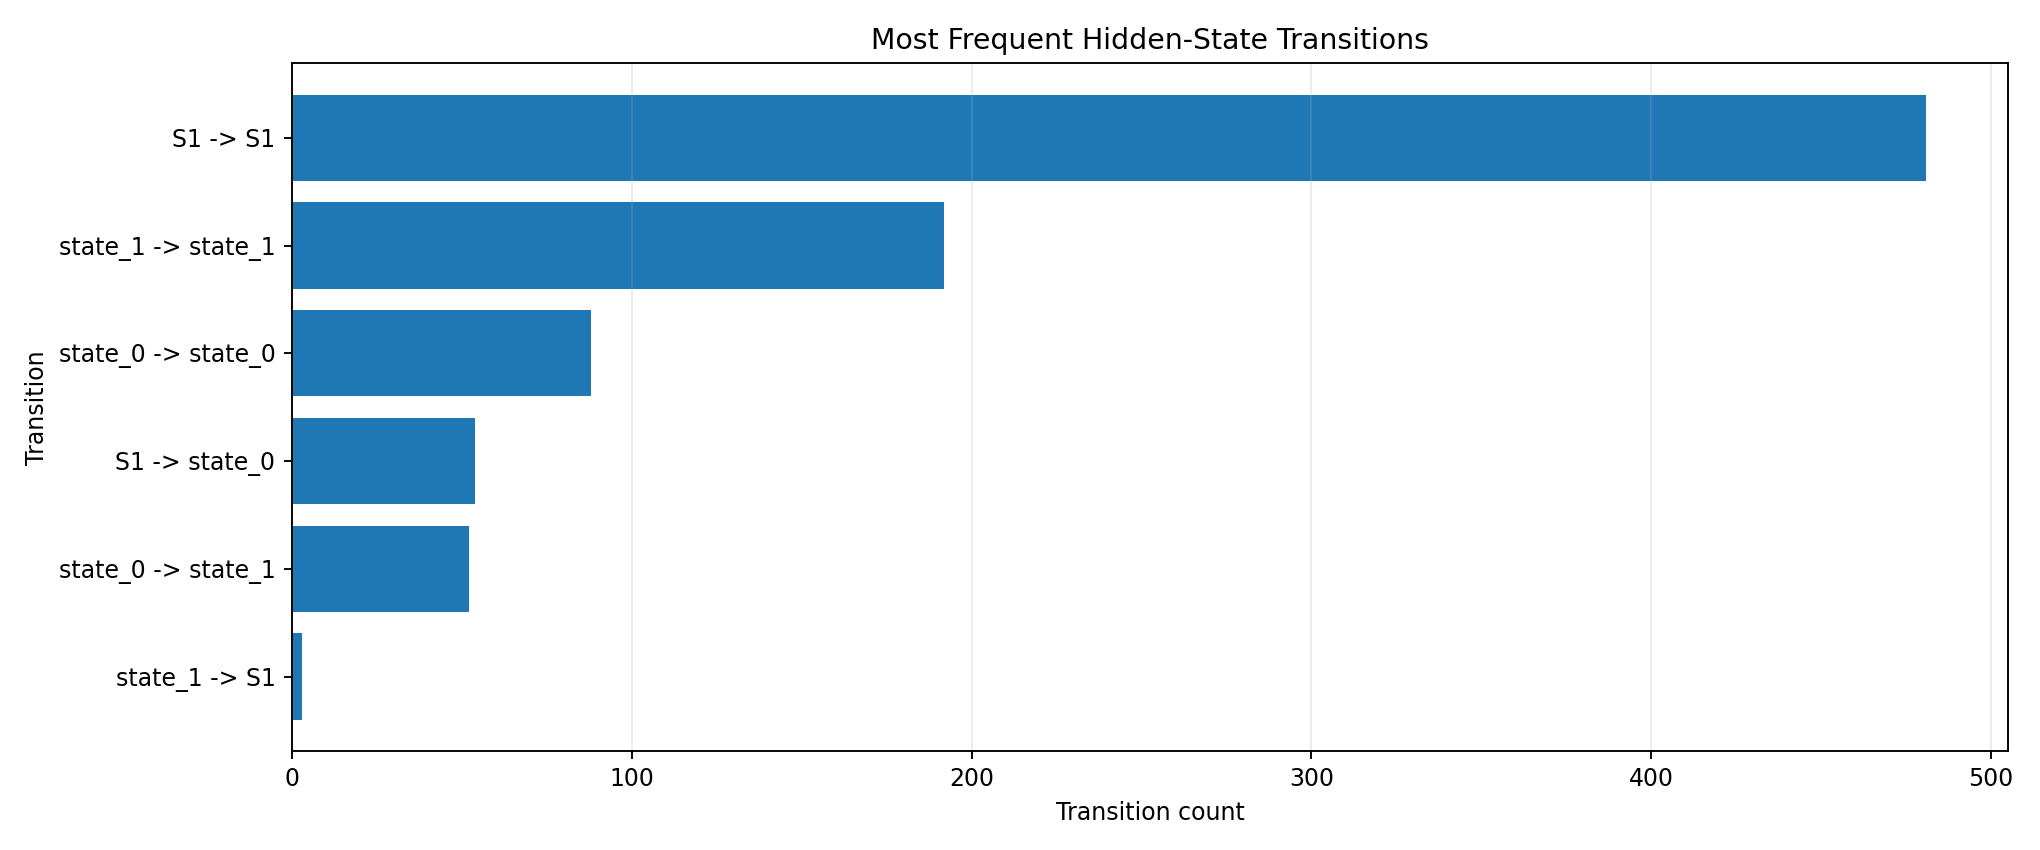

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/athlete_comparative_profile.png


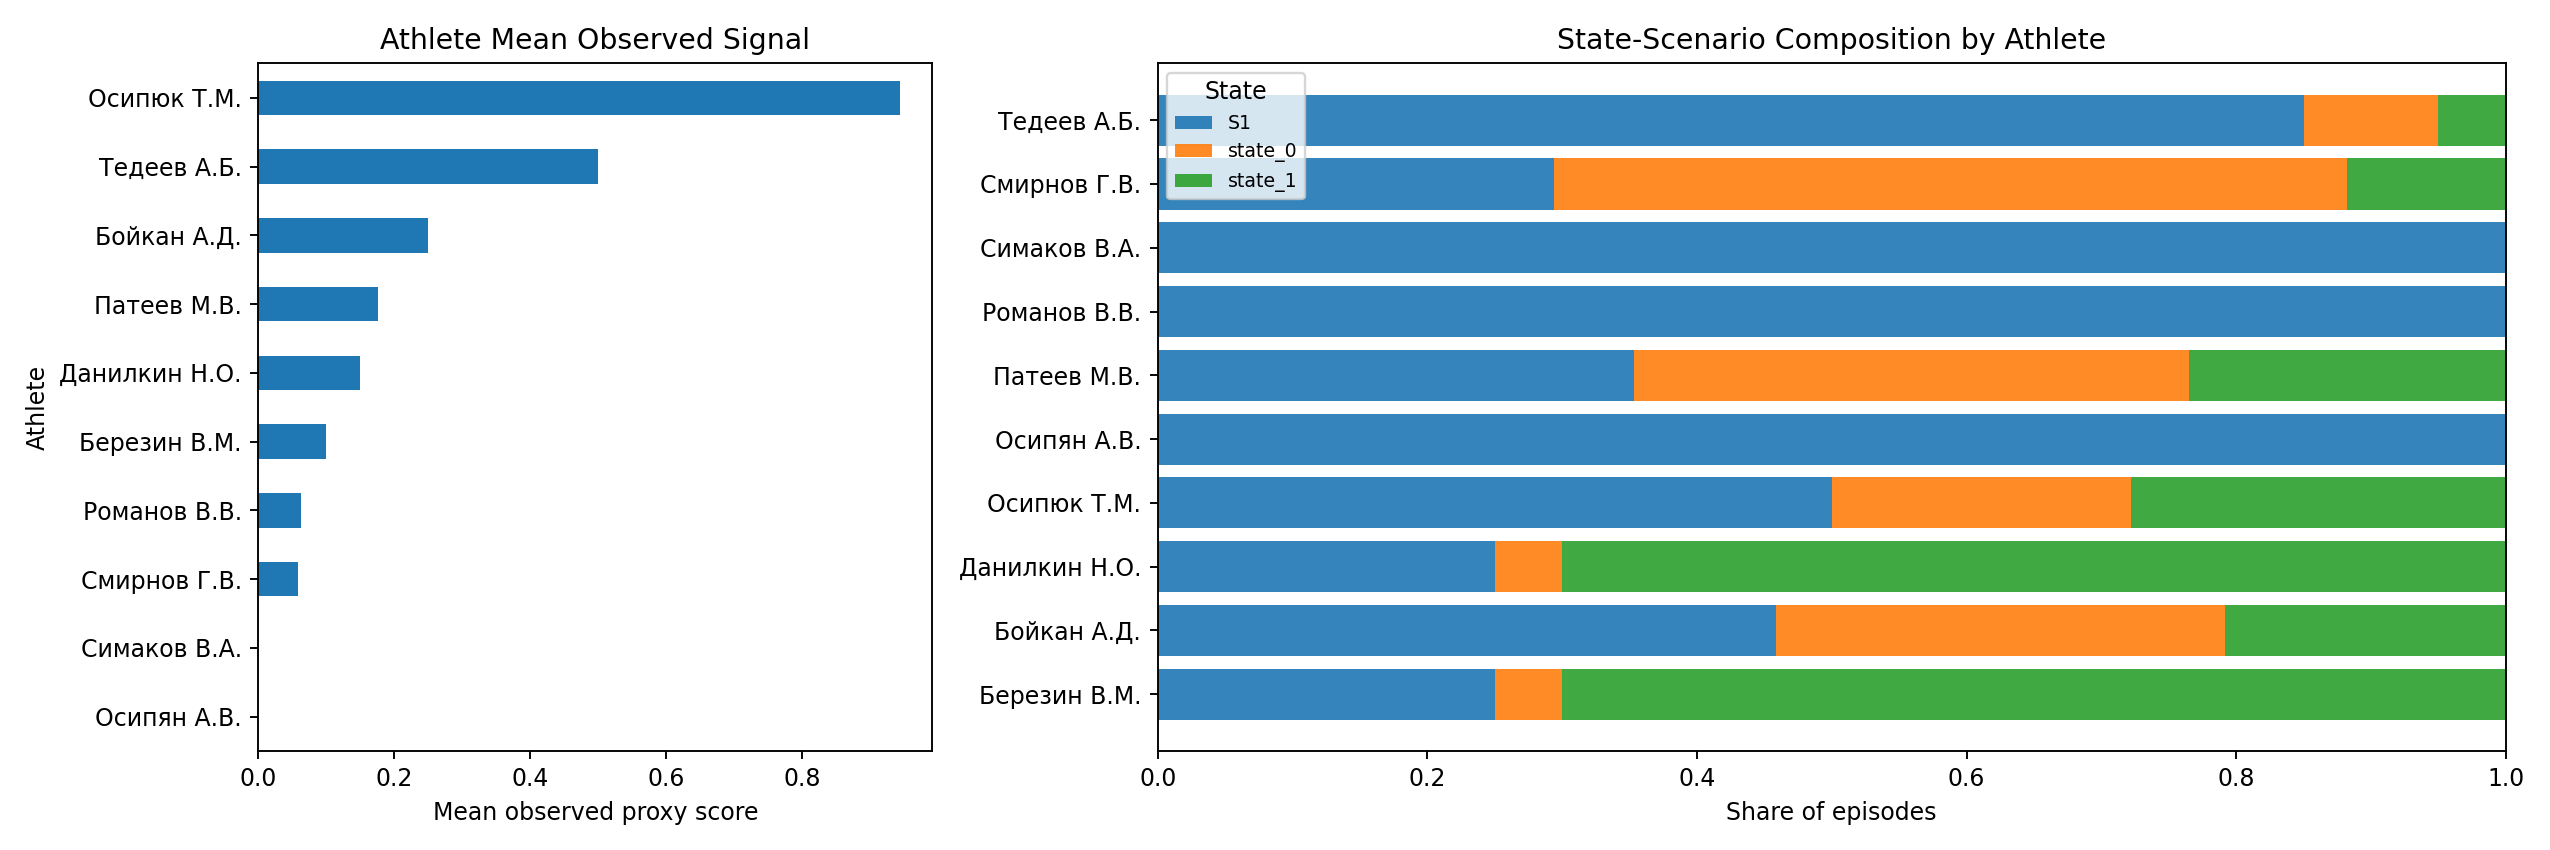

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/scenario_success_frequencies.png


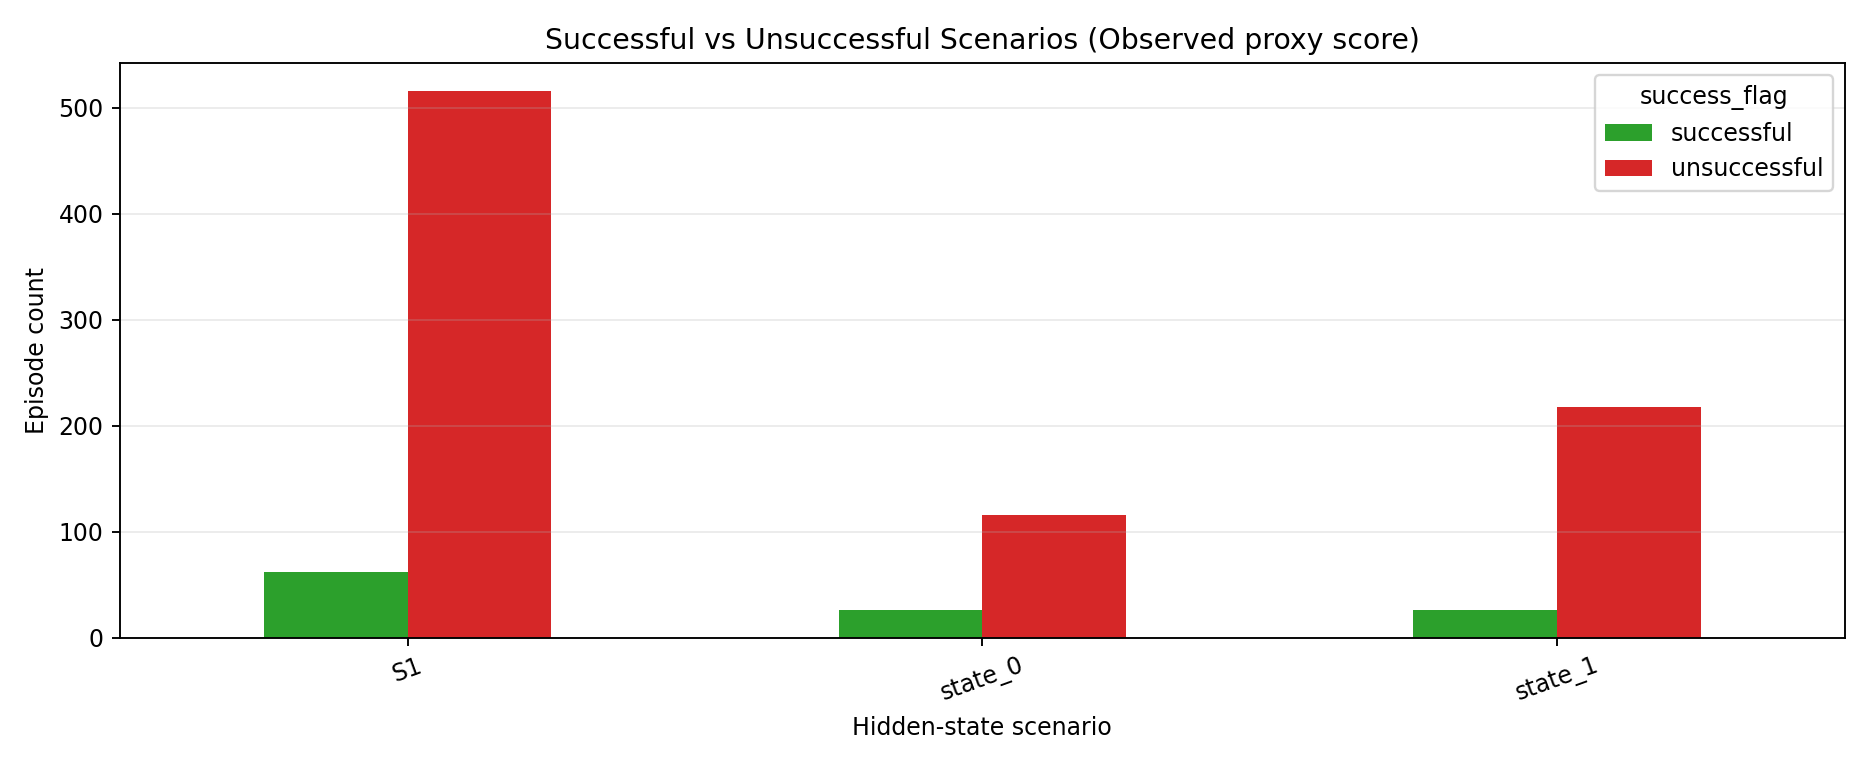

In [5]:
from IPython.display import Image, display

plots_dir = OUTPUT_DIR / "plots"
expected_plots = [
    "hidden_state_sequence.png",
    "state_probability_profile.png",
    "transition_distribution.png",
    "athlete_comparative_profile.png",
    "scenario_success_frequencies.png",
]

shown = set()

if plots_dir.exists():
    for name in expected_plots:
        path = plots_dir / name
        if path.exists():
            print(f"Showing: {path}")
            display(Image(filename=str(path)))
            shown.add(path.name)
        else:
            print(f"Missing plot (skip): {path}")

    for extra_path in sorted(plots_dir.glob("*.png")):
        if extra_path.name not in shown:
            print(f"Showing extra plot: {extra_path}")
            display(Image(filename=str(extra_path)))
else:
    print(f"Plots directory not found: {plots_dir}")


In [6]:
print("Run completed. Artifacts:")
print(f"- Model: {MODEL_PATH}")
print(f"- Diagnostics: {OUTPUT_DIR / 'diagnostics'}")
print(f"- Plots: {OUTPUT_DIR / 'plots'}")
print(f"- Report: {OUTPUT_DIR / 'reports' / 'full_cycle_report.md'}")


Run completed. Artifacts:
- Model: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl
- Diagnostics: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics
- Plots: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots
- Report: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/reports/full_cycle_report.md
